# Precomputed Green's Function Tables

The analytic GF has 30-70% shape errors in the $\mu\to y$ transition ($3\times10^4 < z < 10^5$): the true intermediate shape is not a linear combination of $M(x)$ and $Y_{\rm SZ}(x)$. CosmoTherm-style fix: precompute $G_{\rm th}(x, z_h)$ from PDE runs, interpolate.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spectroxide import (
    apply_style, solve, greens_function,
    load_or_build_greens_table,
    j_bb_star, j_mu,
)
apply_style()

## 1. Build a heating GF table

`load_or_build_greens_table` loads an existing cache or, on first call, runs the PDE at each $z_h$ (parallelised in the Rust binary), normalises by $\Delta\rho/\rho$, and interpolates onto a uniform output grid. Demo uses 30 redshifts; production tables use 150+. Pass `rebuild=True` to force a fresh build.

In [6]:
z_grid = np.logspace(3, np.log10(5e6), 30)
table = load_or_build_greens_table(
    z_injections=z_grid, n_points=2000,
    z_end=100,                     # stop at recombination — no thermalization below
    number_conserving=True,
    cache_path='demo_greens_table.npz',
)
print(f'g_th: {table.g_th.shape}  (N_x={len(table.x)}, N_z={len(table.z_h)})')
print(f'z_h: [{table.z_h[0]:.0e}, {table.z_h[-1]:.0e}]   x: [{table.x[0]:.3f}, {table.x[-1]:.1f}]')

g_th: (500, 30)  (N_x=500, N_z=30)
z_h: [1e+03, 5e+06]   x: [0.010, 30.0]


## 2. Inspect spectra at sampled $z_h$


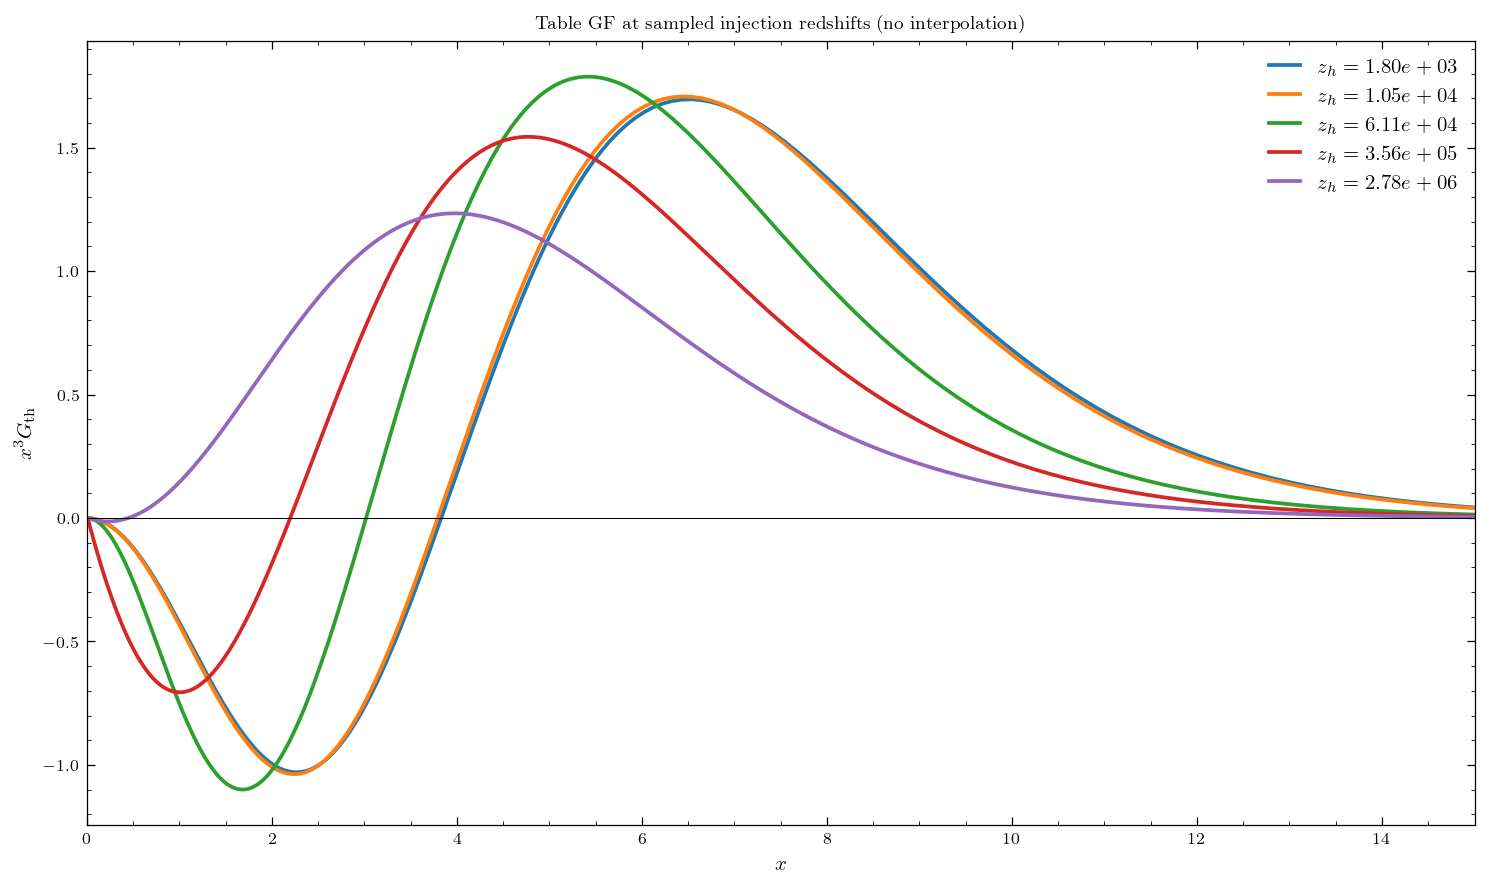

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in np.linspace(2, len(table.z_h) - 3, 5).astype(int):
    zh = table.z_h[i]
    ax.plot(table.x, table.x**3 * table.g_th[:, i], lw=1.8, label=f'$z_h={zh:.2e}$')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$x^3 G_{\rm th}$', xlim=(0, 15),
       title='Table GF at sampled injection redshifts (no interpolation)')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## 3. Analytic vs table vs PDE in the transition

At $z_h=5\times10^4$, the analytic GF errs the most; the table matches the PDE up to interpolation error.


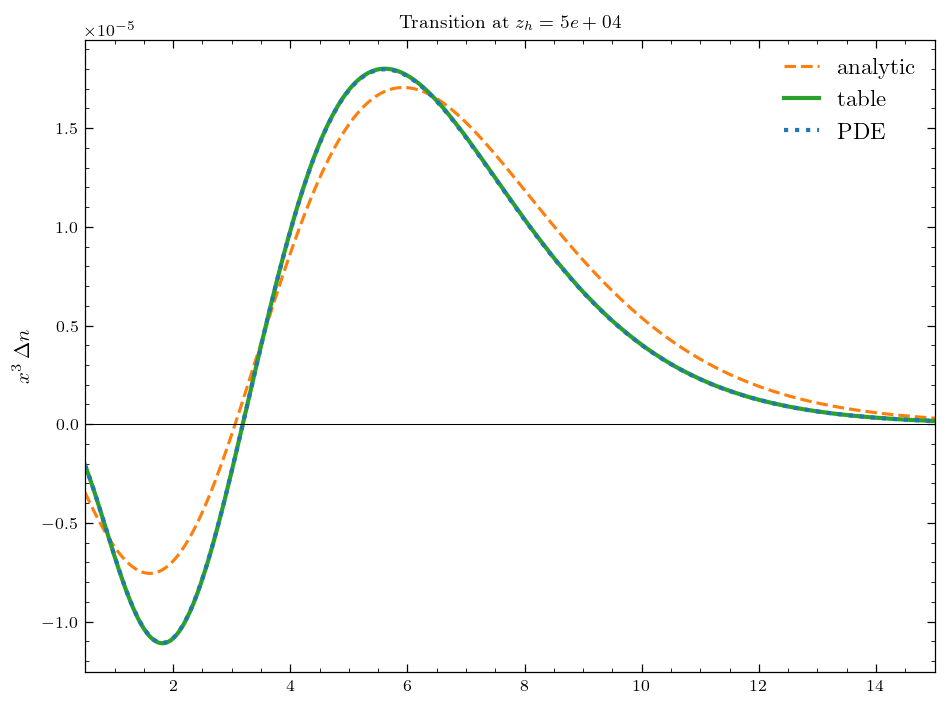

RMS frac. error (x in [0.5,15]): analytic=308.4%, table=0.0%


In [14]:
z_test = 5e4
delta_rho = 1e-5
x_plot = np.logspace(np.log10(0.05), np.log10(25), 500)
dn_an = greens_function(x_plot, z_test) * delta_rho
dn_t  = table.greens_function(x_plot, z_test) * delta_rho
r_pde = solve(injection={'type': 'single_burst', 'z_h': z_test},
              delta_rho=delta_rho, number_conserving=True)

plt.plot(x_plot,    x_plot**3    * dn_an,         'C1--', lw=1.5, label='analytic')
plt.plot(x_plot,    x_plot**3    * dn_t,          'C2-',  lw=2,   label='table')
plt.plot(r_pde.x,   r_pde.x**3   * r_pde.delta_n, 'C0:',  lw=2,   label='PDE')
plt.axhline(0, color='k', lw=0.5)
plt.ylabel(r'$x^3\,\Delta n$')
plt.xlim(0.5, 15)
plt.title(rf'Transition at $z_h={z_test:.0e}$')
plt.legend(fontsize=11)

dn_pde = np.interp(x_plot, r_pde.x, r_pde.delta_n)
mask = np.abs(dn_pde) > 1e-15
denom = np.max(np.abs(dn_pde))
plt.tight_layout()
plt.show()

err_an = np.sqrt(np.mean(((dn_an - dn_pde)/denom)[mask]**2))*100
err_t  = np.sqrt(np.mean(((dn_t  - dn_pde)/denom)[mask]**2))*100
print(f'RMS frac. error (x in [0.5,15]): analytic={err_an:.1f}%, table={err_t:.1f}%')

## 4. Convolve with a DM-decay heating rate

$d(\Delta\rho/\rho)/dz = f_X\Gamma_X e^{-\Gamma_X t(z)} / [H(z)(1+z)]$.


/home/bakerem/miniforge3/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3577: UserWarning: Analytic Green's function has 8-13% spectral shape errors in the mu-y transition region (3e4 < z < 2e5). For percent-level accuracy, use the PDE-based Green's function table:
  table = spectroxide.load_or_build_greens_table()
  dn = table.distortion_from_heating(x, dq_dz, z_min, z_max)
  exec(code_obj, self.user_global_ns, self.user_ns)


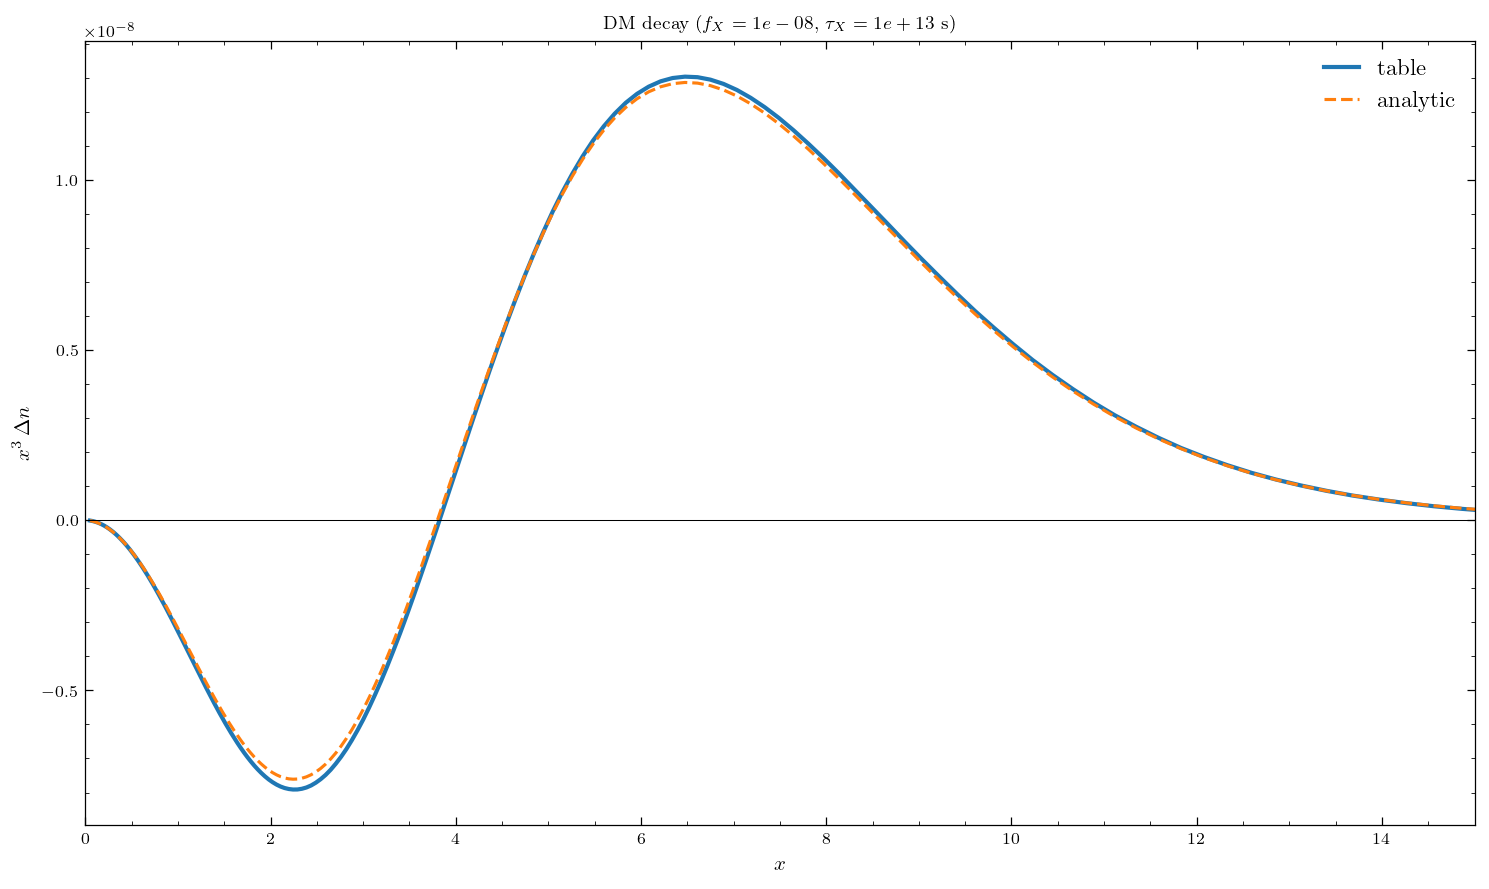

table: mu=9.1140e-12, y=1.9339e-09


In [15]:
from spectroxide import hubble, cosmic_time, distortion_from_heating

f_x, tau_x = 1e-8, 1e13
gamma_x = 1.0 / tau_x
def dm_decay(z):
    return f_x * gamma_x * np.exp(-gamma_x * cosmic_time(z)) / (hubble(z) * (1+z))

x_out = np.logspace(np.log10(0.05), np.log10(25), 300)
dn_t_dm  = table.distortion_from_heating(x_out, dm_decay, z_min=1e3, z_max=5e6)
dn_an_dm = distortion_from_heating(x_out, dm_decay, z_min=1e3, z_max=5e6)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_out, x_out**3 * dn_t_dm,  'C0-',  lw=2,   label='table')
ax.plot(x_out, x_out**3 * dn_an_dm, 'C1--', lw=1.5, label='analytic')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15),
       title=rf'DM decay ($f_X={f_x:.0e}$, $\tau_X={tau_x:.0e}$ s)')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

mu_t, y_t = table.mu_y_from_heating(dm_decay, z_min=1e3, z_max=5e6)
print(f'table: mu={mu_t:.4e}, y={y_t:.4e}')


## 5. Caching and `solve(method="table")`

`load_or_build_greens_table` loads from disk if present, else builds. `solve(method="table", table=...)` plugs the table into the unified API.


In [16]:
import time
t0 = time.time()
table2 = load_or_build_greens_table(cache_path='demo_greens_table.npz')
print(f'load from cache: {time.time()-t0:.3f} s')
assert np.allclose(table.g_th, table2.g_th)
assert np.allclose(table.mu,   table2.mu)

r = solve(method='table', z_h=5e4, delta_rho=1e-5, table=table)
print(f'solve(method=table): mu={r.mu:.4e}, y={r.y:.4e}')


load from cache: 0.074 s
solve(method=table): mu=1.3231e-06, y=4.6953e-06


## Summary

| Function | Purpose |
|---|---|
| `load_or_build_greens_table` | Heating GF table (cache-aware) |
| `load_or_build_photon_greens_table` | Photon-injection GF (3D, cache-aware) |
| `table.greens_function(x, z_h)` | Evaluate tabulated PDE GF |
| `table.distortion_from_heating(x, dq_dz, ...)` | Convolve heating history |
| `table.mu_y_from_heating(dq_dz, ...)` | Compute $\mu, y$ |
| `solve(method='table', table=...)` | Unified API |

Tables fix the $\mu\to y$ transition shape error of the analytic GF and run at interpolation speed. Pass `rebuild=True` to either loader to force a fresh PDE build.